### 第 04 章 函数近似


#### 本章概述

本章将介绍如何从处理离散、有限状态空间的表格型方法（Tabular Methods），过渡到能够处理连续、高维状态空间的函数近似（Function Approximation）方法。这是现代深度强化学习（Deep Reinforcement Learning）的基石。

**学习目标**：
- 理解为什么需要引入函数近似（解决状态空间爆炸与泛化问题）。
- 掌握值函数近似（Value Function Approximation）的基本原理和目标函数。
- 实现基于线性特征和神经网络（非线性）的函数近似方法。
- 认识函数近似在强化学习中带来的挑战（如“致命三要素”）。

**前置知识**：
- 需要掌握前面章节的马尔可夫决策过程（MDP）、蒙特卡洛方法（MC）以及时序差分学习（TD）等基础强化学习算法。
- 具备基本的机器学习知识（如梯度下降）和 PyTorch 基础。


##### 4.1 从表格方法到函数近似


**理论部分**

在之前的章节中，我们使用表格（Table）来存储状态值函数 $V(s)$ 或状态-动作值函数 $Q(s, a)$。例如，对于每一个状态 $s$，我们都在一个数组或字典中为它保留一个位置来记录其价值。这种方法被称为**表格型方法（Tabular Methods）**。

然而，在实际应用中，状态空间往往极其庞大甚至是连续的：
1. **维度灾难（Curse of Dimensionality）**：例如围棋的状态数约为 $10^{170}$，自动驾驶的摄像头输入（像素图像）构成的连续状态空间更是天文数字。计算机无法分配足够的内存来存储所有状态的价值。
2. **泛化能力（Generalization）**：在极其庞大的状态空间中，智能体不可能在有限的训练时间内遍历所有的状态。我们需要智能体在遇到**未见过的状态**时，能够根据过去在相似状态下的经验，合理地推断出当前状态的价值。表格型方法将每个状态视为完全独立的实体，缺乏泛化能力。

**函数近似（Function Approximation）**：
为了解决这些问题，我们引入一个参数化的数学函数来近似真实的值函数：
$$ \hat{v}(s, \mathbf{w}) \approx v_\pi(s) $$
$$ \hat{q}(s, a, \mathbf{w}) \approx q_\pi(s, a) $$

其中 $\mathbf{w} \in \mathbb{R}^d$ 是权重向量（参数），其维度 $d$ 通常远远小于状态空间的规模。当我们更新价值时，我们不再直接修改某个特定状态的独立值，而是**更新整体参数 $\mathbf{w}$**。这样一来，更新一个状态的经验不仅改变了该状态的预测值，也会“泛化”地影响到特征空间中其他相似状态的价值预测。

**关键要点**：
- 表格型方法受限于内存和泛化能力，无法解决高维或连续状态空间问题。
- 函数近似通过有限的参数 $\mathbf{w}$ 拟合价值函数，实现了状态间的泛化。
- 常见的近似函数包括线性函数、决策树、以及深度神经网络等。


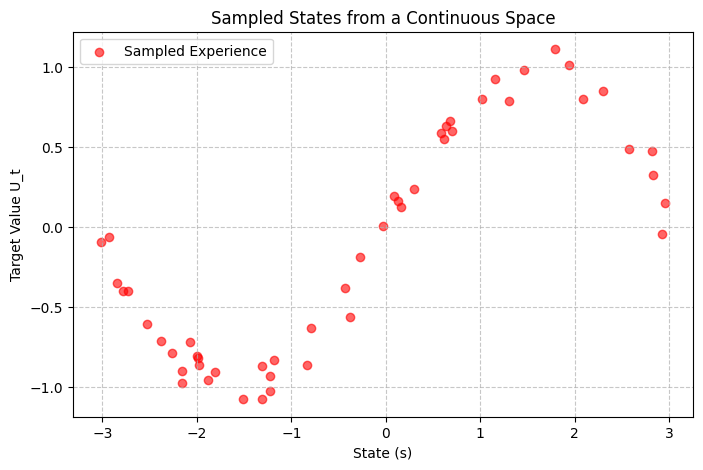

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 我们通过一个简单的回归示例来演示为什么需要近似
# 假设这是环境真实的价值函数 (例如: v(s) = sin(s) + 噪声)
def true_value_function(s):
    return np.sin(s)

# 智能体在环境中交互，只随机访问到了部分连续状态并获得了带有噪声的价值估计 (Target)
np.random.seed(42)
sampled_states = np.random.uniform(-np.pi, np.pi, 50)
sampled_targets = true_value_function(sampled_states) + np.random.normal(0, 0.1, 50)

plt.figure(figsize=(8, 5))
plt.scatter(sampled_states, sampled_targets, label="Sampled Experience", color='red', alpha=0.6)
plt.title("Sampled States from a Continuous Space")
plt.xlabel("State (s)")
plt.ylabel("Target Value U_t")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 我们无法用表格记录这无限连续的区间，接下来我们将用函数拟合它。


##### 4.2 线性函数近似


**理论部分**

线性函数近似是最简单、最易于理论分析的近似方法。在这种方法中，我们首先将原始状态 $s$ 转换为一个**特征向量（Feature Vector）** $\mathbf{x}(s) = [x_1(s), x_2(s), \dots, x_d(s)]^T$。

值函数被建模为特征向量与权重向量 $\mathbf{w}$ 的内积：
$$ \hat{v}(s, \mathbf{w}) = \mathbf{w}^T \mathbf{x}(s) = \sum_{i=1}^d w_i x_i(s) $$

**梯度下降与参数更新**：
在强化学习中，我们希望最小化预测值 $\hat{v}(S_t, \mathbf{w})$ 与某种目标值 $U_t$ 之间的均方误差（MSE）。由于真实的 $v_\pi(S_t)$ 未知，我们使用 $U_t$ 作为替代目标：
- 在蒙特卡洛（MC）方法中，$U_t = G_t$（实际累积回报）。
- 在 TD(0) 方法中，$U_t = R_{t+1} + \gamma \hat{v}(S_{t+1}, \mathbf{w})$（自举估计）。

目标损失函数为：
$$ J(\mathbf{w}) = \mathbb{E}_\pi \left[ \frac{1}{2} (U_t - \hat{v}(S_t, \mathbf{w}))^2 \right] $$

利用随机梯度下降（SGD）对损失函数求导以更新参数：
$$ \mathbf{w}_{t+1} = \mathbf{w}_t + \alpha \left[ U_t - \hat{v}(S_t, \mathbf{w}_t) \right] \nabla_\mathbf{w} \hat{v}(S_t, \mathbf{w}_t) $$

由于是线性近似，梯度计算非常简单：$\nabla_\mathbf{w} \hat{v}(S_t, \mathbf{w}) = \mathbf{x}(S_t)$。因此最终的更新公式为：
$$ \mathbf{w}_{t+1} = \mathbf{w}_t + \alpha \left[ U_t - \hat{v}(S_t, \mathbf{w}_t) \right] \mathbf{x}(S_t) $$

**关键要点**：
- 线性近似具有唯一的全局最优解（或局部最优就是全局最优），训练极其稳定。
- 其核心难点在于**特征工程（Feature Engineering）**：你需要手动设计良好的特征（如多项式基、傅里叶基、径向基函数 RBF 或瓦片编码 Tile Coding）来捕捉状态的非线性。
- 更新直观：误差越大，权重调整越多；特征越显著的维度，更新幅度越大。


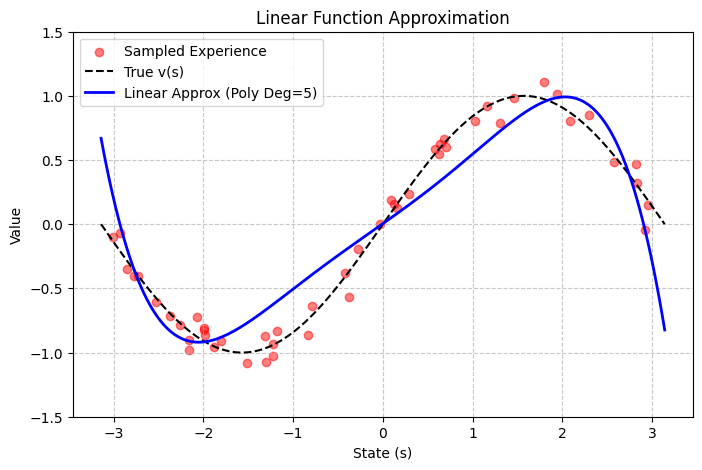

In [2]:
# 使用线性函数近似拟合上述采样经验
# 特征工程: 我们采用多项式特征 x(s) = [1, s, s^2, s^3, ...]

class LinearValueApproximator:
    def __init__(self, degree=3, lr=0.01):
        self.degree = degree
        self.lr = lr
        # 初始化权重向量 w，多项式阶数+1代表特征维度
        self.w = np.zeros(degree + 1)
        
    def extract_features(self, s):
        # 提取多项式特征向量
        return np.array([s**i for i in range(self.degree + 1)])
        
    def predict(self, s):
        # V(s) = w^T * x(s)
        features = self.extract_features(s)
        return np.dot(self.w, features)
        
    def update(self, s, target):
        # 执行一步随机梯度下降 (SGD)
        features = self.extract_features(s)
        prediction = self.predict(s)
        error = target - prediction
        # 权重更新公式: w <- w + lr * error * x(s)
        self.w += self.lr * error * features

# 初始化一个 5 阶多项式的线性近似器
linear_approx = LinearValueApproximator(degree=5, lr=0.00001)

# 模拟训练过程（多轮拟合采样数据）
epochs = 10000
for _ in range(epochs):
    for s, target in zip(sampled_states, sampled_targets):
        linear_approx.update(s, target)

# 生成测试用的连续状态以观察拟合曲线
test_states = np.linspace(-np.pi, np.pi, 200)
linear_predictions = [linear_approx.predict(s) for s in test_states]

plt.figure(figsize=(8, 5))
plt.scatter(sampled_states, sampled_targets, label="Sampled Experience", color='red', alpha=0.5)
plt.plot(test_states, true_value_function(test_states), label="True v(s)", linestyle='--', color='black')
plt.plot(test_states, linear_predictions, label="Linear Approx (Poly Deg=5)", color='blue', linewidth=2)
plt.title("Linear Function Approximation")
plt.xlabel("State (s)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-1.5, 1.5)
plt.show()


##### 4.3 非线性函数近似


**理论部分**

虽然线性函数近似简单且具有优秀的收敛保证，但在应对极其复杂的环境时（例如以图像像素作为输入的 Atari 游戏、复杂的机器人连续控制），**人工设计特征（Feature Engineering）变得极其困难且耗时**。依靠人工经验无法找出一组能够完美表征复杂高维状态的最佳特征。

这促成了 **深度强化学习（Deep Reinforcement Learning, DRL）** 的诞生：使用 **深度神经网络（Deep Neural Networks, DNN）** 作为非线性函数近似器。
$$ \hat{v}(s, \mathbf{w}) = \text{NeuralNet}(s; \mathbf{w}) $$

神经网络最强大的优势在于其**表征学习（Representation Learning）**能力。给定原始的、高维的输入（如像素），神经网络的隐层能自动提取出逐层抽象的特征，最终输出价值预测。

更新规则与线性方法本质相同，依旧是通过反向传播（Backpropagation）计算梯度并进行梯度下降：
$$ \mathbf{w}_{t+1} = \mathbf{w}_t + \alpha \left[ U_t - \hat{v}(S_t, \mathbf{w}_t) \right] \nabla_\mathbf{w} \hat{v}(S_t, \mathbf{w}_t) $$

借助于现代深度学习框架（如 PyTorch / TensorFlow），这些梯度的推导与更新都可以被自动且高效地计算出来。

**关键要点**：
- 神经网络拥有强大的非线性表达能力，实现了端到端的学习（End-to-end Learning），免去了手动特征工程的烦恼。
- 针对不同类型的状态输入，可选用不同的网络结构：
  - **向量输入**：多层感知机（MLP）
  - **图像输入**：卷积神经网络（CNN）
  - **序列/部分可观测输入**：循环神经网络（RNN/LSTM）
- **代价**：非线性近似失去了收敛到全局最优的理论保证。优化目标变得非凸（Non-convex），训练更容易陷入局部最优、不稳定甚至发散。


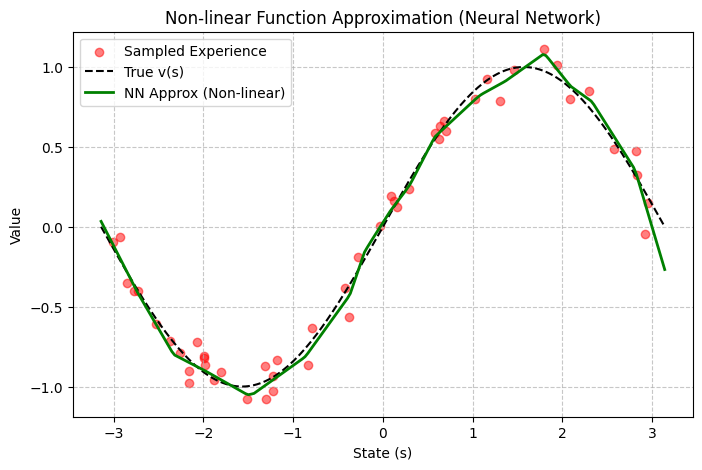

In [3]:
# 使用 PyTorch 构建神经网络进行非线性函数近似

# 定义一个简单的多层感知机 (MLP) 神经网络
class NeuralNetApproximator(nn.Module):
    def __init__(self, hidden_size=64):
        super(NeuralNetApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),      # 输入层到隐藏层
            nn.ReLU(),                      # 激活函数引入非线性
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)       # 隐藏层到输出层 (标量价值)
        )
        
    def forward(self, state):
        return self.net(state)

# 将 Numpy 数组转换为 PyTorch 要求的 Tensor 格式 (N, 1)
states_tensor = torch.FloatTensor(sampled_states).unsqueeze(1)
targets_tensor = torch.FloatTensor(sampled_targets).unsqueeze(1)

# 实例化网络、设置优化器和损失函数
nn_approx = NeuralNetApproximator(hidden_size=32)
optimizer = torch.optim.Adam(nn_approx.parameters(), lr=0.01)
loss_fn = nn.MSELoss()  # 均方误差损失

# 训练网络
epochs_nn = 500
for epoch in range(epochs_nn):
    # 前向传播：计算预测值
    predictions = nn_approx(states_tensor)
    
    # 计算损失
    loss = loss_fn(predictions, targets_tensor)
    
    # 反向传播与参数更新
    optimizer.zero_grad()  # 清空过往梯度
    loss.backward()        # 自动计算梯度
    optimizer.step()       # 更新参数

# 评估并可视化结果
nn_approx.eval() # 切换至评估模式
with torch.no_grad():
    test_states_tensor = torch.FloatTensor(test_states).unsqueeze(1)
    # 计算预测结果并转回 Numpy
    nn_predictions = nn_approx(test_states_tensor).squeeze().numpy()

plt.figure(figsize=(8, 5))
plt.scatter(sampled_states, sampled_targets, label="Sampled Experience", color='red', alpha=0.5)
plt.plot(test_states, true_value_function(test_states), label="True v(s)", linestyle='--', color='black')
plt.plot(test_states, nn_predictions, label="NN Approx (Non-linear)", color='green', linewidth=2)
plt.title("Non-linear Function Approximation (Neural Network)")
plt.xlabel("State (s)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


##### 4.4 函数近似的挑战


**理论部分**

将函数近似（尤其是强大的深度神经网络）直接插入到传统的强化学习算法（如 Q-learning）中，并不能保证算法能顺利工作。相反，它往往会引发严重的稳定性和收敛性危机。

强化学习先驱 Richard Sutton 提出了著名的**“致命三要素”（The Deadly Triad）**概念。当强化学习算法同时满足以下三个条件时，价值函数的估计极易变得不稳定，甚至发散到无穷大：

1. **函数近似（Function Approximation）**：使用能够跨状态泛化的参数化函数（如神经网络）。这导致对状态 A 的价值更新不可避免地影响到状态 B 的价值。
2. **自举（Bootstrapping）**：更新目标并非完全来自真实环境的反馈（如蒙特卡洛回报），而是依赖于对未来状态的现有价值估计（例如 TD 学习或 Q-learning 中的目标包含 $\max_a \hat{Q}(s', a, \mathbf{w})$）。简单来说，就是在“用自己的错误预测来更新自己”。
3. **离策略训练（Off-policy Training）**：用于生成数据的行为策略（Behavior Policy）与正在评估或优化的目标策略（Target Policy）分布不一致。例如在 Q-learning 中，使用 $\epsilon$-greedy 策略探索环境收集数据，但在更新目标时却直接最大化获取贪婪动作的 Q 值。这使得智能体拟合的数据分布存在严重偏差。

**除了致命三要素，基于神经网络的强化学习还面临以下挑战**：
- **数据相关性（Data Correlation）与非静态性（Non-stationarity）**：在传统的监督学习中，我们假设数据是独立同分布（i.i.d.）的，且标签是静态固定的。而在强化学习中：
  - **相关性**：智能体在环境中的连续几帧状态高度相似，时序相关性极强，容易导致神经网络迅速过拟合到这一小段轨迹。
  - **非静态性**：随着策略的更新，智能体访问的数据分布在不断改变；同时，由于自举（Bootstrapping）机制，我们的“目标标签”（Target）本身也是不断变动的。用不断移动的目标来训练神经网络是极不稳定的。
- **灾难性遗忘（Catastrophic Forgetting）**：智能体在学习新任务或进入状态空间的新区域时，神经网络更新后的参数可能会彻底破坏之前在旧区域学到的知识。

**突破口**：
解决上述问题的探索，直接催生了现代深度强化学习技术的爆发。为了打破数据相关性和解决目标非静态问题，2013年 DeepMind 在处理 Atari 游戏时引入了**经验回放（Experience Replay）**和**独立的目标网络（Target Network）**机制，从而诞生了举世闻名的 **深度 Q 网络（DQN）**。这部分内容将在下一章进行详细探讨。

**关键要点**：
- 必须牢记“致命三要素”：函数近似 + 自举 + 离策略 = 训练不稳定/发散风险。
- 强化学习数据的时序相关性和非静态目标极大挑战了传统深度学习优化的前提。
- 函数近似既是连接强化学习与复杂现实问题的桥梁，也是算法稳定性分析中的核心矛盾点。


#### 本章小结

本章我们完成了从简单的表格型方法到现代函数近似方法的跨越。

**主要收获**：
- 认识到了处理高维/连续空间时，使用参数化函数进行状态泛化与压缩的必要性。
- 学习并实现了基于特征工程的线性函数近似，理解了其梯度下降过程的直观意义和收敛稳定性。
- 将深度神经网络引入强化学习作为非线性函数近似器，借助其强大的特征学习能力解决复杂高维输入问题。
- 深入探讨了将函数近似引入强化学习所带来的挑战，尤其是致命三要素引发的稳定性危机，为下一章学习 DQN 的核心改进（经验回放与目标网络）埋下了伏笔。

**关键概念回顾**：
- 表格型方法（Tabular Methods）vs 函数近似（Function Approximation）
- 维度灾难与泛化能力（Curse of Dimensionality & Generalization）
- 线性近似特征（Linear Features）与梯度下降（Gradient Descent）
- 表征学习（Representation Learning）与深度强化学习（DRL）
- 致命三要素（The Deadly Triad）
- 强化学习中的数据相关性与非静态目标
